In [1]:
# import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
from matplotlib import colormaps as cmap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
# import bisect
# import uuid
from enum import Enum
# import requests
from pathlib import Path
import os
from shapely.geometry import Polygon
from shapely.plotting import patch_from_polygon

from fame import *
# import copy
import random
R_earth_km = 6371

## Create the satellites

In [2]:
tle_file_name_json = "tles/all_tles_{}.json".format(dt.datetime.now().strftime("%Y%m%d"))
tle_file_name_txt = "tles/all_tles_{}.txt".format(dt.datetime.now().strftime("%Y%m%d"))
space_track_user = os.environ.get('SPACE_TRACK_USER'), 
space_track_password = os.environ.get('SPACE_TRACK_PW')

if Path(tle_file_name_txt).is_file():
    pass
else:
    if Path(tle_file_name_json).is_file():
        pass
    else:
        all_tles_for_today = get_gp_tles(tle_file_name_json, space_track_user, space_track_password)
    process_tles_from_json(tle_file_name_json, tle_file_name_txt)

In [3]:
# tle_file_name_txt = "all_tles_20260130.txt"

In [4]:
swaths_at_nadir_km = {
    "SKYSAT-A": 8, # https://www.eoportal.org/satellite-missions/skysat#SkySat.html.53, https://earth.esa.int/eogateway/missions/skysat#instruments-section
    "SKYSAT-B": 8,
    "SKYSAT-C1": 5.9,
    "SKYSAT-C2": 5.9,
    "SKYSAT-C3": 5.9,
    "SKYSAT-C4": 5.9,
    "SKYSAT-C5": 5.9,
    "SKYSAT-C6": 5.9,
    "SKYSAT-C7": 5.9,
    "SKYSAT-C8": 5.9,
    "SKYSAT-C9": 5.9,
    "SKYSAT-C10": 5.9,
    "SKYSAT-C11": 5.9,
    "SKYSAT-C12": 5.9,
    "SKYSAT-C13": 5.9,
    "PELICAN-3001": 8, # https://www.planet.com/constellations/pelican/
    "PELICAN-3009": 8,
    "PELICAN-300A": 8,
    "PELICAN-300B": 8,
    "PELICAN-5": 8,
    "PELICAN-6": 8,
    "TANAGER-4001": 18, # https://www.planet.com/constellations/tanager/
    "UMBRA-07": 8, # https://umbra.space/remote-sensing/scan-mode/
    "UMBRA-09": 8, 
    "UMBRA-10": 8,
    "UMBRA-11": 8, 
    "CAPELLA-11 (ACADIA-1)": 10, #https://support.capellaspace.com/what-are-capellas-collect-modes and https://geokom.ba/wp-content/uploads/2020/12/Capella_Space_SAR_System_Performance.pdf
    "CAPELLA-13 (ACADIA-3)": 10,
    "CAPELLA-14 (ACADIA-4)": 10,
    "CAPELLA-15 (ACADIA-5)": 10,
    "CAPELLA-16 (ACADIA-6)": 10,
    "CAPELLA-17 (ACADIA-7)": 10,
    "LOFT YAM-6": 19.8,
    "Ubotica CogniSat-6 HAMMER": 20,
    "Mission Control Persistence": 100,
    "AEROCUBE 18A": 80,
    "AEROCUBE 18B": 80,
}

# planet_satellites = []
# 14-19 decayed


skysat_satellites = [
    Satellite("SKYSAT-A",   Orbital("SKYSAT 1",   tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-B",   Orbital("SKYSAT 2",   tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C1",  Orbital("SKYSAT C1",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    # Satellite("SKYSAT-C1", Orbital("SKYSAT C1", tle_file=tle_file_name_txt)),
    Satellite("SKYSAT-C2",  Orbital("SKYSAT C2",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C3",  Orbital("SKYSAT C3",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C4",  Orbital("SKYSAT C4",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C5",  Orbital("SKYSAT C5",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C6",  Orbital("SKYSAT C6",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C7",  Orbital("SKYSAT C7",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C8",  Orbital("SKYSAT C8",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C9",  Orbital("SKYSAT C9",  tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C10", Orbital("SKYSAT C10", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C11", Orbital("SKYSAT C11", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C12", Orbital("SKYSAT C12", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("SKYSAT-C13", Orbital("SKYSAT C13", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
]


pelican_satellites = [
    Satellite("PELICAN-3001", Orbital("PELICAN-1 3001", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-3009", Orbital("PELICAN-2 3009", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-300A", Orbital("PELICAN-3 300A",    tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-300B", Orbital("PELICAN-4 300B",    tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-5",    Orbital("PELICAN-5 300C",    tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("PELICAN-6",    Orbital("PELICAN-6 300D",    tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
]

tanager_satellites = [
    Satellite("TANAGER-4001", Orbital("TANAGER-1 4001", tle_file=tle_file_name_txt)),

]
# 1-6 and 8 decayed

umbra_satellites = [
    Satellite("UMBRA-07", Orbital("UMBRA-07", tle_file=tle_file_name_txt)),
    Satellite("UMBRA-09", Orbital("UMBRA-09", tle_file=tle_file_name_txt)),
    Satellite("UMBRA-10", Orbital("UMBRA-10", tle_file=tle_file_name_txt)),
    Satellite("UMBRA-11", Orbital("UMBRA-11", tle_file=tle_file_name_txt)),
]

capella_acadia_satellites = [
    Satellite("CAPELLA-11 (ACADIA-1)", Orbital("CAPELLA-11 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-14 (ACADIA-4)", Orbital("CAPELLA-14 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-13 (ACADIA-3)", Orbital("CAPELLA-13 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-15 (ACADIA-5)", Orbital("CAPELLA-15 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-17 (ACADIA-7)", Orbital("CAPELLA-17 (ACADIA)", tle_file=tle_file_name_txt)),
    Satellite("CAPELLA-16 (ACADIA-6)", Orbital("CAPELLA-16 (ACADIA)", tle_file=tle_file_name_txt)),
]
# Whitneys all decayes
# capella_whitney_satellites = [
#     Satellite("CAPELLA-4-WHITNEY",  Orbital("CAPELLA-4-WHITNEY")),
#     Satellite("CAPELLA-3-WHITNEY",  Orbital("CAPELLA-3-WHITNEY")),
#     Satellite("CAPELLA-6-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-5-WHITNEY",  Orbital("CAPELLA-6-WHITNEY")),
#     Satellite("CAPELLA-8-WHITNEY",  Orbital("CAPELLA-8-WHITNEY")),
#     Satellite("CAPELLA-7-WHITNEY",  Orbital("CAPELLA-7-WHITNEY")),
#     Satellite("CAPELLA-10-WHITNEY", Orbital("CAPELLA-10-WHITNEY")),
#     Satellite("CAPELLA-9-WHITNEY",  Orbital("CAPELLA-9-WHITNEY")),
# ]


loft_satellites = [Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB])]

ubotica_satellites = [Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB])]

mission_control_satellites = [Satellite("Mission Control Persistence", Orbital("LEMUR 2 KRISH", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),]

aerospace_corp_satellites = [
    Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),
    Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file=tle_file_name_txt), instruments=[InstrumentType.RGB]),   
]

In [5]:
all_satellites = skysat_satellites+pelican_satellites+tanager_satellites+umbra_satellites+capella_acadia_satellites+loft_satellites+ubotica_satellites+mission_control_satellites+aerospace_corp_satellites

In [6]:
for _sat in all_satellites:
    _semi_major_axis = _sat.orbit.orbit_elements.semi_major_axis * pyorbital.orbital.A
    _mean_altitude = _semi_major_axis-pyorbital.orbital.A
    _fov = 2*np.atan2(swaths_at_nadir_km[_sat.name]/2, _mean_altitude)
    _sat.instrument_fov_rad = {InstrumentType.RGB: _fov}

## Create the target location

In [7]:
Rotterdam = Location(3.8, 52., 0, "Rotterdam-ish")

observables = [Rotterdam,]

## Add some ground stations for contact planning purposes.

These are used by both the constellation managers, and our broker.

In [8]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

In [9]:
start_time = dt.datetime(2026, 2, 14, 0, 0, 0, 0)
end_time = dt.datetime(2026, 2, 16, 0, 0, 0, 0)

### Add some phenomena to observe.

These represent the location of a target of interest, updated at some frequency.

In [10]:
phenomenon_update_frequency = dt.timedelta(seconds=1800)

avg_speed_kph = 37 # 20 kts
start_speed_kph = avg_speed_kph
start_heading_deg = 0
heading_variance = .075
speed_variance = 0.5

phenomena = [
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=start_time,
        end_time=start_time+phenomenon_update_frequency,
        name = Rotterdam.name,
        heading_deg=start_heading_deg,
        speed_kph=start_speed_kph
    ),
]


max_iters_per_point = 5000


start_speed_kph = avg_speed_kph
start_heading_deg = 0

new_heading_rad = start_heading_deg*np.pi/180.

random.seed(4)

while phenomena[-1].end_time<end_time:
    next_point_is_on_land = True
    _it_guesses = 0
    while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
        _it_guesses+=1
        
        # new_heading_rad = random.random()*2*math.pi # 0 at North
        new_heading_rad += random.normalvariate()*heading_variance # 0 at North

        new_speed_kph = avg_speed_kph + random.normalvariate()*speed_variance
        dy = new_speed_kph*np.cos(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # E-W
        dx = new_speed_kph*np.sin(new_heading_rad)*(phenomenon_update_frequency.total_seconds()/3600) # N-S

        dlat_rad = dy/R_earth_km
        dlon_rad = dx/(R_earth_km*np.cos(phenomena[-1].lat_deg*math.pi/180.))

        new_lat_deg = phenomena[-1].lat_deg + dlat_rad*180./math.pi
        new_lon_deg = phenomena[-1].lon_deg + dlon_rad*180./math.pi

        next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)

    if (_it_guesses==max_iters_per_point-1):
        raise ValueError("Could not find a way to stay on land")
    previous_end_time = phenomena[-1].end_time
    

    phenomena.append(
        Phenomenon(
            lon_deg = new_lon_deg,
            lat_deg = new_lat_deg,
            alt_km=Rotterdam.alt_km,
            start_time=previous_end_time,
            end_time=previous_end_time+phenomenon_update_frequency,
            heading_deg=new_heading_rad*180./np.pi,
            speed_kph=new_speed_kph,
            name = Rotterdam.name+ " {}-{}".format(previous_end_time.strftime("%Y-%m-%d, %H"),(previous_end_time+phenomenon_update_frequency).strftime("%H"))
        ),
    )

phenomena_with_stationary_toi = [p for p in phenomena]

phenomena_with_stationary_toi.append(
    Phenomenon(
        lon_deg = Rotterdam.lon_deg,
        lat_deg = Rotterdam.lat_deg,
        alt_km=Rotterdam.alt_km,
        start_time=start_time,
        end_time=end_time,
        name = Rotterdam.name+ " stationary"
    ),
)

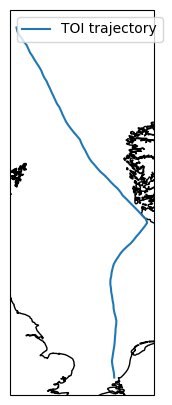

In [11]:
figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

axglobal.plot([pos.lon_deg for pos in phenomena],[pos.lat_deg for pos in phenomena],transform=ccrs.Geodetic(), label="TOI trajectory")


axglobal.legend()


Manually add observation opportunities

In [12]:
sim_start_time = start_time

In [13]:
world_with_brokers = World(satellites = all_satellites, phenomena=phenomena)

scheduler_planet = ConstellationGroundScheduler(satellites=skysat_satellites+pelican_satellites+tanager_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Planet")
scheduler_umbra = ConstellationGroundScheduler(satellites=umbra_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Umbra")
scheduler_capella = ConstellationGroundScheduler(satellites=capella_acadia_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Capella")
scheduler_LOFT = ConstellationGroundScheduler(satellites=loft_satellites, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=ubotica_satellites, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_mission_control = ConstellationGroundScheduler(satellites=mission_control_satellites, ground_stations=ground_stations, world=world_with_brokers, name="Mission Control")
scheduler_aerospace = ConstellationGroundScheduler(satellites=aerospace_corp_satellites, ground_stations=ground_stations, world=world_with_brokers, name="AC")

world_with_brokers.add_constellation(scheduler_planet)
world_with_brokers.add_constellation(scheduler_umbra)
world_with_brokers.add_constellation(scheduler_capella)
world_with_brokers.add_constellation(scheduler_LOFT)
world_with_brokers.add_constellation(scheduler_ubotica)
world_with_brokers.add_constellation(scheduler_mission_control)
world_with_brokers.add_constellation(scheduler_aerospace)




world_with_brokers = World(satellites = all_satellites, phenomena=phenomena)

# N_BACKGROUND_SAMPLES_PER_CONSTELLATION = 50


# sampled_world_cities_LOFT = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES_PER_CONSTELLATION,weights='population',axis=0, random_state=0)
# sampled_world_cities_ubotica = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES_PER_CONSTELLATION,weights='population',axis=0, random_state=1)
# sampled_world_cities_aerospace = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES_PER_CONSTELLATION,weights='population',axis=0, random_state=2)
# obs_request_LOFT = [
#     ObservationRequest(city[1].lng, city[1].lat, min_time=start_time, max_time=end_time, alt_km=0.307, request_name=city[1].city,)
#     for city in sampled_world_cities_LOFT.iterrows()
# ]
# obs_request_ubotica = [
#     ObservationRequest(city[1].lng, city[1].lat, min_time=start_time, max_time=end_time, alt_km=0.307, request_name=city[1].city,)
#     for city in sampled_world_cities_ubotica.iterrows()
# ]
# obs_request_aerospace = [
#     ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=min_time, alt_km=0.307, request_name=city[1].city,)
#     for city in sampled_world_cities_aerospace.iterrows()
# ]


# for request in obs_request_LOFT:
#     scheduler_LOFT.schedule_request(
#         request=request,
#         current_time=sim_start_time,
#         callback_request_scheduled=lambda obs: print("[LOFT] Request {} scheduled for observation {}!".format(request, obs)),
#         callback_request_ready=lambda dp: print("[LOFT] Request {} ready with DP {}!".format(request, dp)),
#         )
    
# for request in obs_request_ubotica:
#     scheduler_ubotica.schedule_request(
#         request=request,
#         current_time=sim_start_time,
#         callback_request_scheduled=lambda obs: print("[UBOTICA] Request {} scheduled for observation {}!".format(request, obs)),
#         callback_request_ready=lambda dp: print("[UBOTICA] Request {} ready with DP {}!".format(request, dp)),
#         )
    
# for request in obs_request_aerospace:
#     scheduler_aerospace.schedule_request(
#         request=request,
#         current_time=sim_start_time,
#         callback_request_scheduled=lambda obs: print("[AC] Request {} scheduled for observation {}!".format(request, obs)),
#         callback_request_ready=lambda dp: print("[AC] Request {} ready with DP {}!".format(request, dp)),
#         )
    
# scheduler_LOFT.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_ubotica.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_aerospace.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))

In [14]:
broker = Broker(constellations=[scheduler_planet, scheduler_umbra, scheduler_capella, scheduler_LOFT, scheduler_ubotica, scheduler_mission_control, scheduler_aerospace], world=world_with_brokers)

world_with_brokers.add_broker(broker)

In [15]:
# # Let's do everything broker-side for now.
# # When we receive an observation, we update the ship tracker.
# # Periodically we query the ship tracker with a next set of search locations, which are passed to the broker.
# # For the temporal aspect, we just query periodically.
# # For the spatial aspect, let's start with "last known location"

# class ShipTracker():
#     def __init__(self, initial_pose: Pose, pose_propagator=None):
#         self.last_measurement_time = initial_pose.time
#         self.last_update_time = initial_pose.time

#         self.estimated_locations = [initial_pose,]
        
#         if pose_propagator is None:
#             # Stationary propagator
#             def pose_propagator(_previous_pose: Pose, deltat: dt.timedelta):
#                 _new_pose = Pose(
#                     time=_previous_pose.time+deltat,
#                     lon_deg=_previous_pose.lon_deg,
#                     lat_deg=_previous_pose.lat_deg,
#                     alt_km=_previous_pose.alt_km,
#                     heading_deg=_previous_pose.heading_deg,
#                     speed_kph=_previous_pose.speed_kph
#                     )
#                 return _new_pose
        
#         self.propagator = pose_propagator

#     def update_location(self, new_detection: Pose):
#         self.estimated_locations = [new_detection,]

#         self.last_update_time = new_detection.time
#         self.last_measurement_time = new_detection.time

#     def propagate_locations(self, new_time: dt.datetime, samples: int=10):
#         new_estimated_locations = []
#         for _location in self.estimated_locations:
#             for _ in range(samples):
#                 new_estimated_locations.append(self.propagator(_location, new_time-self.last_update_time))
#         self.estimated_locations = new_estimated_locations
#         self.last_update_time = new_time

#     def prune_locations(self, samples: int=100):
#         if len(self.estimated_locations)>samples:
#             self.estimated_locations = random.sample(self.estimated_locations, samples)

#     def plan_next_search_locations(self, current_time, max_search_time, max_search_locations=10, observation_interval: dt.timedelta=dt.timedelta(seconds=10*60)):
#         # Idea:
#         # - Generate a bunch of points sampling the possible current location of the ship
#         # - Come up with a tessellation that covers these points
#         # - Return those as search areas
#         self.propagate_locations(current_time)
#         self.prune_locations()
#         all_obs_requests = []
#         for i in range(int(np.ceil((max_search_time-current_time).total_seconds()/observation_interval.total_seconds()))):
#             for _pose in random.sample(self.estimated_locations, max_search_locations):
#                 _obs_min_time = current_time+observation_interval*i
#                 _obs_max_time = current_time+observation_interval*(i+1)
#                 _obs_center_time = current_time+observation_interval*(i+.5)
#                 _propagated_pose = self.propagator(_pose, _obs_center_time-_pose.time)
#                 _request = ObservationRequest(
#                     lat_deg=_propagated_pose.lat_deg,
#                     lon_deg=_propagated_pose.lon_deg,
#                     min_time=_obs_min_time,
#                     max_time = _obs_max_time,
#                     alt_km=_propagated_pose.alt_km,
#                     instrument=InstrumentType.RGB,
#                     request_name="Ship_{}-{}".format(_obs_min_time.strftime("%Y-%m-%d %H:%M:%S"), _obs_max_time.strftime("%Y-%m-%d %H:%M:%S")),
#                     min_elevation_deg=45,
#                 )
#                 all_obs_requests.append(_request)
#         # all_obs_requests = [
#         #     ObservationRequest(
#         #         lat_deg=_pose.lat_deg,
#         #         lon_deg=_pose.lon_deg,
#         #         min_time=current_time+observation_interval*i,
#         #         max_time = current_time+observation_interval*(i+1),
#         #         alt_km=_pose.alt_km,
#         #         instrument=InstrumentType.RGB,
#         #         request_name="Ship_{}-{}".format(current_time.strftime("%Y-%m-%d %H:%M:%S"), max_search_time.strftime("%Y-%m-%d %H:%M:%S")),
#         #         min_elevation_deg=45,
#         #     ) for _pose in random.sample(self.estimated_locations, max_search_locations)
#         #     for i in range(int(np.ceil((max_search_time-current_time).total_seconds()/observation_interval.total_seconds())))
#         # ]
#         return all_obs_requests
    

In [16]:
# def ship_propagator(previous_pose: Pose, deltat: dt.timedelta, heading_variance: float = 1, speed_variance: float=1, max_speed_if_unspecified_kph = 37):
#     next_point_is_on_land = True
#     _it_guesses = 0
#     max_iters_per_point = 5000
#     while (next_point_is_on_land and _it_guesses<max_iters_per_point):
        
#         _it_guesses+=1
        
#         # new_heading_rad = random.random()*2*math.pi # 0 at North
#         if (previous_pose.heading_deg is not None):
#             new_heading_rad = previous_pose.heading_deg*np.pi/180. + random.normalvariate()*heading_variance # 0 at North
#         else:
#             new_heading_rad = random.uniform(-np.pi, np.pi)

#         if (previous_pose.speed_kph is not None):
#             new_speed_kph = previous_pose.speed_kph + random.normalvariate()*speed_variance
#         else:
#             new_speed_kph = random.uniform(0, max_speed_if_unspecified_kph)

#         dy = new_speed_kph*np.cos(new_heading_rad)*(deltat.total_seconds()/3600) # E-W
#         dx = new_speed_kph*np.sin(new_heading_rad)*(deltat.total_seconds()/3600) # N-S

#         dlat_rad = dy/R_earth_km
#         dlon_rad = dx/(R_earth_km*np.cos(previous_pose.lat_deg*math.pi/180.))

#         new_lat_deg = previous_pose.lat_deg + dlat_rad*180./math.pi
#         new_lon_deg = previous_pose.lon_deg + dlon_rad*180./math.pi
#         new_heading_deg = new_heading_rad*180./math.pi

#         next_point_is_on_land = is_land(new_lon_deg, new_lat_deg)
#     if (_it_guesses==max_iters_per_point-1):
#         raise ValueError("Could not find a way to stay on land")

#     return Pose(
#         time=previous_pose.time+deltat,
#         lon_deg=new_lon_deg,
#         lat_deg=new_lat_deg,
#         alt_km=previous_pose.alt_km,
#         speed_kph=new_speed_kph,
#         heading_deg=new_heading_deg
#         )

# def custom_phenomenon_processor(observation: ObservationOpportunity, spacecraft: Satellite, phenomenon: Phenomenon):
#     return Pose(
#         lon_deg=phenomenon.lon_deg,
#         lat_deg = phenomenon.lat_deg,
#         time=observation.time,
#         alt_km=phenomenon.alt_km,
#         heading_deg=phenomenon.heading_deg,
#         speed_kph=phenomenon.speed_kph,
#         name=phenomenon.name
#     )

In [17]:
_ship_tracker = ShipTracker(
    initial_pose=Pose(time=dt.datetime.now(),lon_deg=Rotterdam.lon_deg, lat_deg=Rotterdam.lat_deg, alt_km=Rotterdam.alt_km, heading_deg=0, speed_kph=37),
    pose_propagator=lambda _pp, _dt: ship_propagator(_pp, _dt, heading_variance=heading_variance, speed_variance=speed_variance)
    )

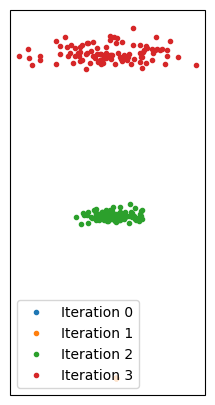

In [22]:

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
# axglobal.set_global()
axglobal.coastlines()

axglobal.plot([pos.lon_deg for pos in _ship_tracker.estimated_locations],[pos.lat_deg for pos in _ship_tracker.estimated_locations],'.', transform=ccrs.Geodetic(), label="Iteration 0")


_ship_tracker.propagate_locations(new_time=dt.datetime.now()+dt.timedelta(seconds=900))
_ship_tracker.prune_locations()
axglobal.plot([pos.lon_deg for pos in _ship_tracker.estimated_locations],[pos.lat_deg for pos in _ship_tracker.estimated_locations],'.', transform=ccrs.Geodetic(), label="Iteration 1")


_ship_tracker.propagate_locations(new_time=dt.datetime.now()+dt.timedelta(seconds=1800))
_ship_tracker.prune_locations()
axglobal.plot([pos.lon_deg for pos in _ship_tracker.estimated_locations],[pos.lat_deg for pos in _ship_tracker.estimated_locations],'.', transform=ccrs.Geodetic(), label="Iteration 2")


_ship_tracker.propagate_locations(new_time=dt.datetime.now()+dt.timedelta(seconds=2700))
_ship_tracker.prune_locations()
axglobal.plot([pos.lon_deg for pos in _ship_tracker.estimated_locations],[pos.lat_deg for pos in _ship_tracker.estimated_locations],'.', transform=ccrs.Geodetic(), label="Iteration 3")


# _ship_tracker.update_location(new_detection=Pose(time=dt.datetime.now()+dt.timedelta(seconds=3600),lon_deg=Rotterdam.lon_deg, lat_deg=Rotterdam.lat_deg, alt_km=Rotterdam.alt_km, heading_deg=0, speed_kph=20))
# axglobal.plot([pos.lon_deg for pos in _ship_tracker.estimated_locations],[pos.lat_deg for pos in _ship_tracker.estimated_locations],'.', transform=ccrs.Geodetic(), label="Iteration 4")


axglobal.legend()

In [25]:
import geopandas as gpd
import shapely

ship_tracker = _ship_tracker

points_gpd = gpd.GeoDataFrame(
    {'lon': [pos.lon_deg for pos in ship_tracker.estimated_locations], 'lat': [pos.lat_deg for pos in ship_tracker.estimated_locations]},
    geometry=gpd.points_from_xy([pos.lon_deg for pos in ship_tracker.estimated_locations], [pos.lat_deg for pos in ship_tracker.estimated_locations]),
    crs="EPSG:4326"
)

In [32]:
cvx_hull = points_gpd.union_all().convex_hull

In [64]:
import h3

# cvx_hull_json = shapely.geometry.mapping(cvx_hull)

# cvx_hull_h3 = h3.LatLngPoly([(float(pos.lat_deg), float(pos.lon_deg)) for pos in ship_tracker.estimated_locations])
cvx_hull_h3 = h3.geo_to_h3shape(cvx_hull)

h3_cell_ids = h3.h3shape_to_cells_experimental(cvx_hull_h3, res=5, contain='overlap')
print(h3_cell_ids)
h3_cell_boundaries_latlon = [h3.cell_to_boundary(h3_id) for h3_id in h3_cell_ids]
h3_cell_boundaries_lonlat = [[(lon, lat) for lat, lon in lls] for lls in h3_cell_boundaries_latlon]
h3_cell_boundaries_poly = [Polygon(ll) for ll in h3_cell_boundaries_lonlat]

['85196b13fffffff']


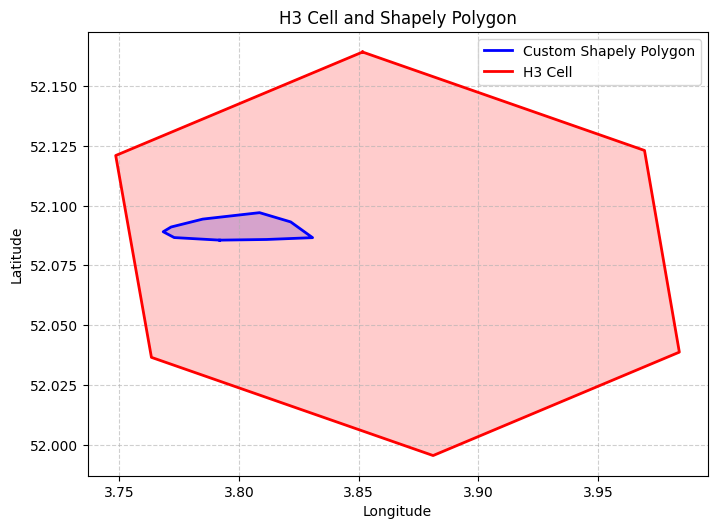

In [61]:
fig, ax = plt.subplots(figsize=(8, 8))

# Extract x, y coordinates and plot the custom Polygon
x_custom, y_custom = cvx_hull.exterior.xy
ax.plot(x_custom, y_custom, color='blue', linewidth=2, label='Custom Shapely Polygon')
ax.fill(x_custom, y_custom, alpha=0.2, color='blue') # Add a light fill

for h3_cell_boundary_poly in h3_cell_boundaries_poly:
    # Extract x, y coordinates and plot the H3 Polygon
    x_h3, y_h3 = h3_cell_boundary_poly.exterior.xy
    ax.plot(x_h3, y_h3, color='red', linewidth=2, label=f'H3 Cell')
    ax.fill(x_h3, y_h3, alpha=0.2, color='red') # Add a light fill

# 4. Formatting
ax.set_aspect('equal') # Crucial: Ensures the map isn't distorted/squished
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('H3 Cell and Shapely Polygon')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)

In [ ]:
# sampled_world_cities_broker = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=3)

number_of_submissions = 999

# OMNISCENT_BROKER = True
# BROKER_ALWAYS_DETECTS_SHIP = True

broker_modes = ['FIXED_GAZE', 'FIXED_GAZE_RT', 'OMNISCENT_BROKER', 'BROKER_ALWAYS_DETECTS_SHIP', 'ACTIVE_DETECTION', 'ACTIVE_DETECTION_WITH_SEARCH']

broker_mode = 'ACTIVE_DETECTION_WITH_SEARCH'

In [ ]:


request_time_interval = dt.timedelta(seconds=3600)

# obs_requests_broker = [
#     ObservationRequest(Rotterdam.lon_deg, Rotterdam.lat_deg, min_time=start_time+i*request_time_interval, max_time=start_time+(i+1)*request_time_interval, alt_km=0.0, request_name=Rotterdam.name,)
#     for i in range(int(math.ceil((end_time-start_time).total_seconds()/request_time_interval.total_seconds())))
# ]

obs_requests_phenomenon = [
    ObservationRequest(p.lon_deg, p.lat_deg, min_time=p.start_time, max_time=p.end_time, alt_km=p.alt_km, request_name=Rotterdam.name, min_elevation_deg=45)
    for p in phenomena
]

search_interval_s = 1800

if broker_mode == 'FIXED_GAZE':
    # Only look at where the ship started, every 30 minutes. Schedule in advance.
    for i in range(int(math.ceil(48*3600/search_interval_s))):
        _fixed_gaze_request = ObservationRequest(
            Rotterdam.lon_deg, Rotterdam.lat_deg,
            min_time=start_time+dt.timedelta(seconds=search_interval_s)*i,
            max_time=start_time+dt.timedelta(seconds=search_interval_s)*(i+1),
            alt_km=Rotterdam.alt_km, request_name=Rotterdam.name,
            min_elevation_deg=45,
            )
        broker.schedule_request(
            request=_fixed_gaze_request,
            current_time=sim_start_time,
            number_of_submissions=number_of_submissions,
            phenomenon_processor=custom_ship_phenomenon_processor,
            )
    
if broker_mode == 'FIXED_GAZE_RT':
    # Only look at where the ship started, every 30 minutes. Schedule in real time.
    for i in range(int(math.ceil(48*3600/search_interval_s))):
        _min_time = start_time+dt.timedelta(seconds=search_interval_s*i)
        _max_time = start_time+dt.timedelta(seconds=search_interval_s*(i+1))
        _event = Event(
            time=_min_time,
            name="RFixed_{}".format(_min_time),
            action_callable = lambda _mit=_min_time, _mat=_max_time, ns=number_of_submissions: 
            broker.schedule_request(
                request = ObservationRequest(
                    Rotterdam.lon_deg, Rotterdam.lat_deg,
                    min_time=_mit,
                    max_time=_mat,
                    alt_km=Rotterdam.alt_km, request_name=Rotterdam.name,
                    min_elevation_deg=45,
                ),
                current_time=_mit,
                number_of_submissions=ns,
                phenomenon_processor=custom_ship_phenomenon_processor,
                )
        )
        # This schedules the next batch of observations right at the beginning of the window. We expect that there may be loads of conflicts as we don't have enough time to get the request in...
        world_with_brokers.add_event(_event)


elif broker_mode == 'OMNISCENT_BROKER':
    # Schedule all searches at the right place, ahead of time
    for _req in obs_requests_phenomenon:
        broker.schedule_request(
            _req,
            current_time=sim_start_time,
            number_of_submissions=number_of_submissions,
            phenomenon_processor=custom_ship_phenomenon_processor,
            )

elif broker_mode == 'BROKER_ALWAYS_DETECTS_SHIP':
    # Schedule at the right place, just ahead of time
    for _req in obs_requests_phenomenon:
        _event = Event(
            time=_req.min_time,
            name=_req.name,
            action_callable = lambda __req=_req, ct=_req.min_time, ns=number_of_submissions: broker.schedule_request(
                __req,
                current_time=ct,
                number_of_submissions=ns,
                phenomenon_processor=custom_ship_phenomenon_processor,
                )
        )
        # This schedules the next batch of observations right at the beginning of the window. We expect that there may be loads of conflicts as we don't have enough time to get the request in...
        world_with_brokers.add_event(_event)

elif broker_mode == 'ACTIVE_DETECTION' or broker_mode == 'ACTIVE_DETECTION_WITH_SEARCH':
    followup_horizon_s = 7200
    time_to_schedule_followup = 10

    # Event:
    # - schedule an observation
    # - with a callback that does the following:
    #   - update the ShipTracker
    #   - ask for the next location
    #   - schedule a new observation
    # Schedule a first look where we think the ship is.
    # When the information comes back, feed it to ShipTracker.
    # Then immediately invoke ShipTracker to get a new search location.
    # It will always look at the last place where the ship was.
    
    ship_tracker = ShipTracker(
        initial_pose=Pose(time=start_time, lon_deg=Rotterdam.lon_deg, lat_deg=Rotterdam.lat_deg, alt_km=Rotterdam.alt_km, heading_deg=0, speed_kph=37),
        pose_propagator=lambda _pp, _dt: ship_propagator(_pp, _dt, heading_variance=heading_variance, speed_variance=speed_variance)
        )
    
    def get_follow_up_events(_ship_tracker, _current_time, followup_horizon_s, time_to_schedule_followup, number_of_submissions):
        follow_up_observations = _ship_tracker.plan_next_search_locations(
            current_time = _current_time,
            max_search_time=_current_time+dt.timedelta(seconds=followup_horizon_s)
            )
        follow_up_events = []
        for follow_up_observation in follow_up_observations:
            follow_up_events.append(
                Event(
                    time=_current_time+dt.timedelta(seconds=time_to_schedule_followup),
                    action_callable = lambda __req=follow_up_observation, ct=_current_time, ns=number_of_submissions:
                    broker.schedule_request(
                        __req,
                        current_time=ct,
                        number_of_submissions=ns,
                        phenomenon_processor=custom_ship_phenomenon_processor,
                        follow_up_action_success=observation_follow_up # This is the key recursive aspect.
                    ),
                    name="Follow-up search {}".format(_current_time)
                )
            )
        return follow_up_events

    def schedule_follow_up_events(_world: World, _ship_tracker: ShipTracker, followup_horizon_s: int, time_to_schedule_followup: int, number_of_submissions: int ):
        follow_up_events = get_follow_up_events(_ship_tracker, _world.time, followup_horizon_s, time_to_schedule_followup, number_of_submissions) # You can write C in any language, uh.
        for _follow_up_event in follow_up_events:
            # print("&&& [{} ]Adding event {} with time {} to world".format(_world.time, _follow_up_event.name, _follow_up_event.time))
            _world.add_event(_follow_up_event)

    def observation_follow_up(data_product):
        # This fires when a follow-up is detected 
        current_time = world_with_brokers.time #I Think this will be evaluated lazily?
        # Update location
        if data_product is not None:
            if len(data_product)>0:
                if len(data_product)>1:
                    raise Exception("Why do we have multiple detections?")
                # TODO here we need to use the OBSERVATION time, not the current time! Otherwise we will always be lagging.
                ship_tracker.update_location(new_detection=data_product[0])
        
        # Get new observations
        schedule_follow_up_events(
            _world=world_with_brokers,
            _ship_tracker=ship_tracker,
            followup_horizon_s=followup_horizon_s,
            time_to_schedule_followup=time_to_schedule_followup,
            number_of_submissions=number_of_submissions
            )
    
    initial_request = ObservationRequest(
        lon_deg=Rotterdam.lon_deg,
        lat_deg=Rotterdam.lat_deg,
        min_time=start_time,
        max_time=start_time+dt.timedelta(seconds=7200),
        alt_km=0,
        instrument=InstrumentType.RGB,
        request_name="Rotterdam initial",
        min_elevation_deg=45
    )

    initial_event = Event(
        time=start_time,
        action_callable = lambda __req=initial_request, ct=start_time, ns=number_of_submissions:
        broker.schedule_request(
            __req,
            current_time=ct,
            number_of_submissions=ns,
            phenomenon_processor=custom_ship_phenomenon_processor,
            follow_up_action_success=observation_follow_up # This is the key recursive aspect.
            ),
            name="Initial search"
    )

    world_with_brokers.add_event(initial_event)

    if broker_mode == 'ACTIVE_DETECTION_WITH_SEARCH':
         # Same as ACTIVE_DETECTION, plus a search every x minutes.
         # Have an event every 30 mins
         # The event is
         # Get list of observations from the ship searcher
         # Schedule those observations

        search_events = [
            Event(
                time=start_time+dt.timedelta(seconds=search_interval_s)*i,
                action_callable = lambda: schedule_follow_up_events(
                    _world=world_with_brokers,
                    _ship_tracker=ship_tracker,
                    followup_horizon_s=followup_horizon_s,
                    time_to_schedule_followup=time_to_schedule_followup,
                    number_of_submissions=number_of_submissions
                ),
                name="Periodic search trigger"
            )
            for i in range(int(math.ceil(48*3600/search_interval_s)))
        ]
        for _search_event in search_events:
            world_with_brokers.add_event(_search_event)

    # broker.schedule_request(_req, current_time=sim_start_time, number_of_submissions=number_of_submissions)

In [ ]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_brokers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])
    # print(world_with_brokers.events)

In [ ]:
# def request_statistics(requests_pd):
#     total_requests_no = len(requests_pd)
#     all_statuses = set(requests_pd.status.values)    
#     for s in all_statuses:
#         # matching_statuses = sum([1 if (r['status']==s) else 0 for r in requests.values()])
#         matching_statuses = len(requests_pd[requests_pd.status==s])
#         print("{}/{} ({}%) of requests are in status {}".format(matching_statuses,total_requests_no, matching_statuses/total_requests_no*100, s))
#     # X/Y requests have >1 successful observation
    
#     requests_with_detections = requests_pd.apply(lambda x: x['data_product'] is not None and len(x['data_product'])>0, axis=1)

#     if len(requests_pd[requests_pd.status=="OK! Data received"])>0:
#         print("{}/{} ({}%) successful requests have a phenomenon detection".format(sum(requests_with_detections), len(requests_pd[requests_pd.status=="OK! Data received"]),sum(requests_with_detections)/len(requests_pd[requests_pd.status=="OK! Data received"])*100))
    
#     unique_requests = set(requests_pd.request)
#     unique_requests_no = len(unique_requests)
#     fulfilled_unique_requests_no = 0
#     fulfilled_unique_requests_events_found_no = 0
#     for ur in unique_requests:
#         matching_observation_statuses = requests_pd[(requests_pd['request']==ur) & (requests_pd['status']=="OK! Data received")]
#         if len(matching_observation_statuses):
#             fulfilled_unique_requests_no += 1
#         for _dp in matching_observation_statuses['data_product']:
#             if _dp is not None and len(_dp):
#                 fulfilled_unique_requests_events_found_no += 1
#                 break
#     print(" {}/{} ({}%) unique requests have at least one successful observation".format(fulfilled_unique_requests_no, unique_requests_no, fulfilled_unique_requests_no/unique_requests_no*100))
#     # for _ix, _dp in requests_pd:
#     # print(" of all requests have a phenomenon detection")
#     # print(" of all _successful_ requests have a phenomenon detection")

#     # print(" of all unique requests have a phenomenon detection")
#     if fulfilled_unique_requests_no>0:
#         print("{}/{} ({}%) of all successful unique requests have a phenomenon detection".format(fulfilled_unique_requests_events_found_no, fulfilled_unique_requests_no, fulfilled_unique_requests_events_found_no/fulfilled_unique_requests_no*100))

In [ ]:
request_statistics(broker._requests)

TODO:
- [X] Updated position
- [ ] Estimate new position if we change velocity
- [X] Histogram 

In [ ]:
def satcolorer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "midnightblue"
    if "PELICAN" in sat_name:
        return "mediumblue"
    if "TANAGER" in sat_name:
        return "blueviolet"
    # Black
    if "UMBRA" in sat_name:
        return "dimgray"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "darkorange"
    # 
    if "LOFT" in sat_name:
        return "forestgreen"
    #
    if "Ubotica" in sat_name:
        return "lime"
    #
    if "Mission Control" in sat_name:
        return "orchid"
    return "red"
    
def constcolorer(constellation_name):
    # Planet: shades of blue
    if "PLANET" in constellation_name:
        return "blue"
    # Black
    if "UMBRA" in constellation_name:
        return "gray"
    # Yellow/orange
    if "CAPELLA" in constellation_name:
        return "darkorange"
    # 
    if "LOFT" in constellation_name:
        return "forestgreen"
    #
    if "Ubotica" in constellation_name:
        return "lime"
    #
    if "Mission Control" in constellation_name:
        return "orchid"
    return "red"

def satmarkerer(sat_name):
    # Planet: shades of blue
    if "SKYSAT" in sat_name:
        return "p"
    if "PELICAN" in sat_name:
        return "p"
    if "TANAGER" in sat_name:
        return "p"
    # Black
    if "UMBRA" in sat_name:
        return "D"
    # Yellow/orange
    if "CAPELLA" in sat_name:
        return "D"
    # 
    if "LOFT" in sat_name:
        return "p"
    #
    if "Ubotica" in sat_name:
        return "p"
    #
    if "Mission Control" in sat_name:
        return "p"
    return "."

satcolor = {sat.name: satcolorer(sat.name) for sat in all_satellites}

satmarker = {sat.name: satmarkerer(sat.name) for sat in all_satellites}

constcolor = {const.name: constcolorer(const.name) for const in world_with_brokers.constellations}


In [ ]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.coastlines()
_plot_offset_deg = 10

mapcenter = Location(lon_deg=3.8, lat_deg=60, alt_km=0)

axes_extents = (float(mapcenter.lon_deg)-_plot_offset_deg, float(mapcenter.lon_deg)+_plot_offset_deg, float(mapcenter.lat_deg)-_plot_offset_deg, float(mapcenter.lat_deg)+_plot_offset_deg)
ax.set_extent(axes_extents, crs=ccrs.PlateCarree())

for _chronicle in world_with_brokers.history:
    if type(_chronicle['event']) in [ObservationEvent]:
        _ax = plot_event(
            _chronicle,
            world_with_brokers,
            ax=ax,
            satellite_colors=satcolor,
            satellite_markers=satmarker,
            constellation_colors=constcolor,
            plot_time=False,
            plot_phenomena=False,
            plot_satellite_tracks=False,
            plot_ground_stations=False,
            plot_observation_gaze=False,
            plot_observation_target=False,
            plot_satellites=False
            )
        
ax.plot([pos.lon_deg for pos in phenomena],[pos.lat_deg for pos in phenomena],transform=ccrs.Geodetic(), label="TOI trajectory")
plt.savefig("MSA_observations_ship_sigmahdg_{}_sigmav_{}.png".format(heading_variance, speed_variance),bbox_inches='tight')
plt.savefig("MSA_observations_ship_sigmahdg_{}_sigmav_{}.pdf".format(heading_variance, speed_variance),bbox_inches='tight')


In [ ]:
PLOT_HISTORY_TL = True

_plot_offset_deg = 15
axes_extents = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg)

if PLOT_HISTORY_TL:
    plot_history(
        world_with_brokers,
        events_to_show=[ObservationEvent],
        axes_extents=axes_extents,
        satellite_colors=satcolor,
        satellite_markers=satmarker,
        constellation_colors=constcolor,
        plot_observation_target=False,
        )

In [ ]:
figglobal = plt.figure(figsize=(10,5))
ax = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
ax.coastlines()
_plot_offset_deg = 15
axes_extents = (float(Rotterdam.lon_deg)-_plot_offset_deg, float(Rotterdam.lon_deg)+_plot_offset_deg, float(Rotterdam.lat_deg)-_plot_offset_deg, float(Rotterdam.lat_deg)+_plot_offset_deg)
# ax.set_global()
ax.set_extent(axes_extents, crs=ccrs.PlateCarree())


for (_ix, _req) in broker._requests.iterrows():
    ax.plot(_req.request.lon_deg, _req.request.lat_deg,'.', color=('g' if _req.status=="OK! Data received" else 'r'), transform=ccrs.Geodetic())
for (_ix, _req) in broker._requests.iterrows():
    if (_req.status=="OK! Data received"):
        ax.plot(_req.request.lon_deg, _req.request.lat_deg,'d', color='g', markersize=2, transform=ccrs.Geodetic())

# TODO

We estimate a stationary position at time t, and then observe there for the next 1-2h. That's a bit silly and we should make the position dynamic as a function of time. Of course that's hard...